## Conceptual CHAOS SV representation

From the CHAOS B-spline representation to Gauss-coefficient time series and radial SV maps.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import LogNorm

from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *

plt.rcParams.update({"font.size": 11})

['/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']


In [3]:
# Selectors
spline_index = 30
gauss_index = 33
demo_time = 30
nmax = 15

# Recover the 64 B-spline coefficients from CHAOS's stored piecewise-polynomial form
model = cp.load_CHAOS_matfile(CHAOS_DIR / "CHAOS-8.6.mat")
B_full = cp.model_utils.colloc_matrix(times_res_mjd, knots, order, deriv=0)
gnm_mf_full = model.synth_coeffs_tdep(times_res_mjd, nmax=nmax)
spline_coefficients = np.linalg.lstsq(B_full, gnm_mf_full, rcond=None)[0]

# H_sv is the differentiated basis in yr^-1; the reconstructed record is in nT yr^-1
gnm_chaos = H_sv @ spline_coefficients
gauss_indices = np.arange(1, nmax * (nmax + 2) + 1)
spline_colours = plt.cm.viridis(np.linspace(0, 1, n_spl))

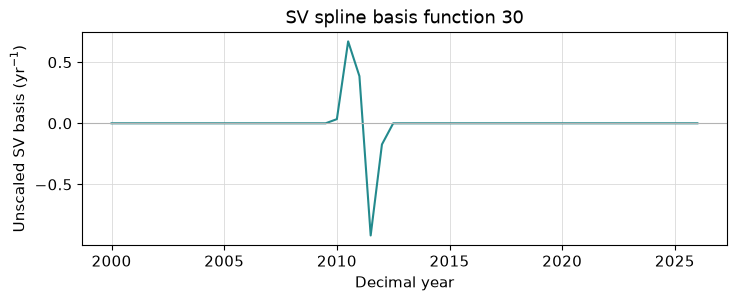

In [24]:
# One unscaled SV spline basis function
fig, ax = plt.subplots(
    figsize=(text_width, 0.4 * text_width), constrained_layout=True
)
ax.plot(times_used, H_sv[:, spline_index], color=spline_colours[spline_index])
ax.axhline(0, color="0.7", linewidth=0.8)
ax.set(
    xlabel="Decimal year",
    ylabel=r"Unscaled SV basis (yr$^{-1}$)",
    title=f"SV spline basis function {spline_index}",
)
ax.grid(True, color="0.85", linewidth=0.6)
plt.show()

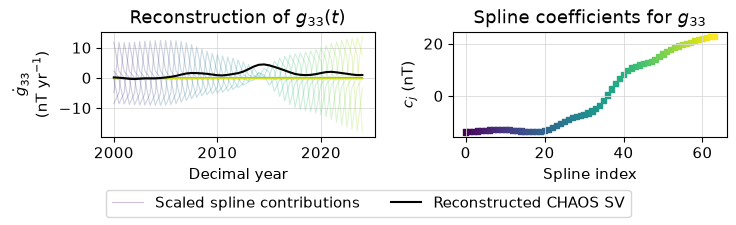

In [4]:
# Reconstruction of one CHAOS SV Gauss-coefficient time series
spline_contributions = H_sv * spline_coefficients[:, gauss_index]

fig, axes = plt.subplots(
    1, 2, figsize=(text_width, 0.3 * text_width), constrained_layout=True
)
for index in range(n_spl):
    axes[0].plot(
        times_used, spline_contributions[:, index], color=spline_colours[index],
        alpha=0.25, linewidth=0.8,
        label="Scaled spline contributions" if index == 0 else None,
    )
axes[0].plot(
    times_used, np.sum(spline_contributions, axis=1),
    color="black", linewidth=1.5, label="Reconstructed CHAOS SV",
)
axes[0].set(
    xlabel="Decimal year",
    ylabel=rf"$\dot{{g}}_{{{gauss_index}}}$" + "\n" + r"(nT yr$^{-1}$)",
    title=rf"Reconstruction of $g_{{{gauss_index}}}(t)$",
)

axes[1].scatter(
    np.arange(n_spl), spline_coefficients[:, gauss_index],
    color=spline_colours, marker="s", s=14,
)
axes[1].set(
    xlabel="Spline index",
    ylabel=r"$c_j$ (nT)",
    title=rf"Spline coefficients for $g_{{{gauss_index}}}$",
)

for ax in axes:
    ax.grid(True, color="0.85", linewidth=0.6)
fig.legend(loc="outside lower center", ncol=2)


plt.savefig(f"{RESULT_DIR}/2_spline_understanding.pdf", bbox_inches="tight")


plt.show()

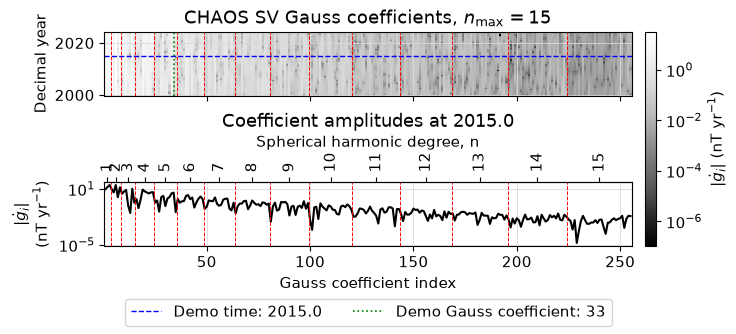

In [5]:
# Full CHAOS SV record and the coefficient amplitudes at demo_time
gauss_amplitude = np.abs(gnm_chaos)
positive_minimum = np.min(gauss_amplitude[gauss_amplitude > 0])
degree_boundaries = np.arange(1, nmax + 1)

fig, axes = plt.subplots(
    2, 1, figsize=(text_width, 0.45 * text_width),
    sharex=True, constrained_layout=True,
)
record_plot = axes[0].pcolormesh(
    gauss_indices, times_used, gauss_amplitude,
    cmap="Greys_r", norm=LogNorm(vmin=positive_minimum, vmax=gauss_amplitude.max()),
    shading="auto",
)
axes[0].set(
    ylabel="Decimal year",
    title=rf"CHAOS SV Gauss coefficients, $n_{{\max}}={nmax}$",
)
fig.colorbar(
    record_plot, ax=axes, pad=0.02,
    label=r"$|\dot{g}_i|$ (nT yr$^{-1}$)",
)
demo_time_line = axes[0].axhline(
    times_used[demo_time], color="blue", linestyle="--", linewidth=1.0,
    label=f"Demo time: {times_used[demo_time]:.1f}",
)
demo_gauss_line = axes[0].axvline(
    gauss_indices[gauss_index], color="green", linestyle=":", linewidth=1.2,
    label=f"Demo Gauss coefficient: {gauss_index}",
)

axes[1].semilogy(
    gauss_indices, gauss_amplitude[demo_time], color="black"
)
for n in degree_boundaries:
    for ax in axes:
        ax.axvline(
            n * (n + 2) + 0.5, color="red", linestyle="--", linewidth=0.7
        )
axes[1].set(
    xlim=(0.5, gauss_indices[-1] + 0.5),
    xlabel="Gauss coefficient index",
    ylabel=r"$|\dot{g}_i|$" + "\n" + r"(nT yr$^{-1}$)",
    title=f"Coefficient amplitudes at {times_used[demo_time]:.1f}",
)
degree_axis = axes[1].secondary_xaxis("top")
degree_axis.set_xticks(
    degree_boundaries * (degree_boundaries + 1), labels=degree_boundaries
)
degree_axis.set_xlabel("Spherical harmonic degree, n")
degree_axis.tick_params(axis="x", labelrotation=90)

for ax in axes:
    ax.grid(True, color="0.85", linewidth=0.6)
fig.legend(
    handles=[demo_time_line, demo_gauss_line],
    loc="outside lower center", ncol=2,
)

plt.savefig(f"{RESULT_DIR}/2_gauss_time_series.pdf", bbox_inches="tight")


plt.show()

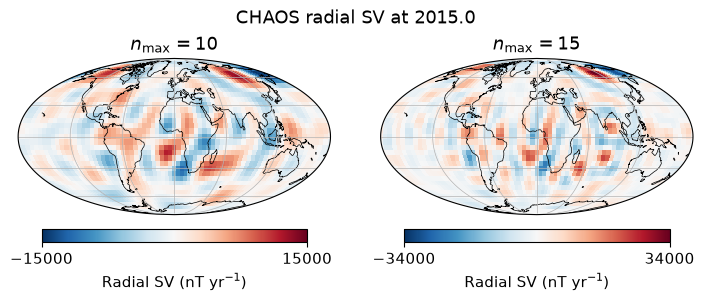

In [6]:
# Radial SV at two spherical harmonic truncations
gnm_demo = gnm_chaos[demo_time]
field_10 = (
    Truncate_Gauss_Coeffs(A_15_r, 10)
    @ Truncate_Gauss_Coeffs(gnm_demo, 10)
).reshape(state_shape)
field_15 = (A_15_r @ gnm_demo).reshape(state_shape)
colour_limits = [
    np.ceil(np.max(np.abs(field_10)) / 1000) * 1000,
    np.ceil(np.max(np.abs(field_15)) / 1000) * 1000,
]

plot_longitude = (longitude + 180) % 360 - 180
longitude_order = np.argsort(plot_longitude)
longitude_cyclic = np.append(plot_longitude[longitude_order], 180)
fields = [field_10, field_15]

fig, axes = plt.subplots(
    1, 2, figsize=(text_width, 0.4 * text_width),
    subplot_kw={"projection": ccrs.Mollweide()}, constrained_layout=True,
)
for ax, field, degree, colour_limit in zip(axes, fields, [10, 15], colour_limits):
    field_sorted = field[:, longitude_order]
    field_cyclic = np.column_stack((field_sorted, field_sorted[:, 0]))
    map_plot = ax.pcolormesh(
        longitude_cyclic, latitude, field_cyclic,
        transform=ccrs.PlateCarree(), cmap="RdBu_r",
        vmin=-colour_limit, vmax=colour_limit, shading="auto",
    )
    ax.coastlines(color="black", linewidth=0.5)
    ax.set_global()
    ax.gridlines(color="0.7", linewidth=0.5)
    ax.set_title(rf"$n_{{\max}}={degree}$")
    cbar = fig.colorbar(
        map_plot, ax=ax, orientation="horizontal", pad=0.08, shrink=0.75,
        label=r"Radial SV (nT yr$^{-1}$)",
    )
    cbar.set_ticks([-colour_limit, colour_limit])

fig.suptitle(f"CHAOS radial SV at {times_used[demo_time]:.1f}")

plt.savefig(f"{RESULT_DIR}/2_chaos_truncation_demo.pdf", bbox_inches="tight")

plt.show()